In [20]:
import kagglehub

path = kagglehub.dataset_download("rohiteng/amazon-sales-dataset")

print("Path:", path)


Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Path: /kaggle/input/amazon-sales-dataset


In [21]:
import os
import pandas as pd
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_file:
  csv_path=os.path.join(path,csv_file[0])
  df=pd.read_csv(csv_path)
  print('csv file',{csv_path},'imported sucessfully')
else:
  df=None
  print('error')

csv file {'/kaggle/input/amazon-sales-dataset/Amazon.csv'} imported sucessfully


In [22]:
df.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  object 
 15  OrderStatus    100000 non-null  object 
 16  City           100000 non-null  object 
 17  State          100000 non-null

In [24]:
df.isnull().sum()

,0
OrderID,0
OrderDate,0
CustomerID,0
CustomerName,0
ProductID,0
ProductName,0
Category,0
Brand,0
Quantity,0
UnitPrice,0


In [25]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.drop(['OrderID', 'CustomerID', 'ProductID', 'CustomerName', 'ProductName', 'SellerID'], axis=1, inplace=True)

In [28]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['month'] = df['OrderDate'].dt.month
df['day'] = df['OrderDate'].dt.day

In [29]:
essential_cols = [
    'Quantity',
    'UnitPrice',
    'Discount',
    'Tax',
    'ShippingCost',
    'TotalAmount'
]

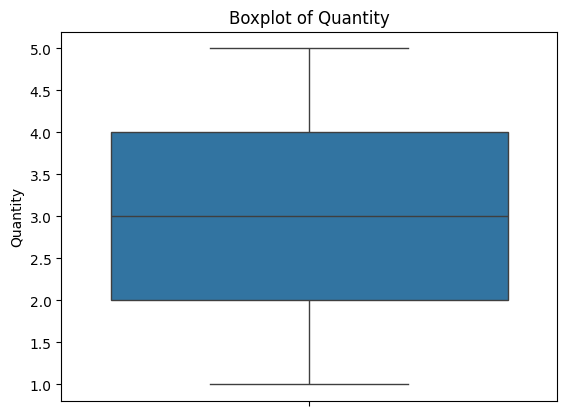

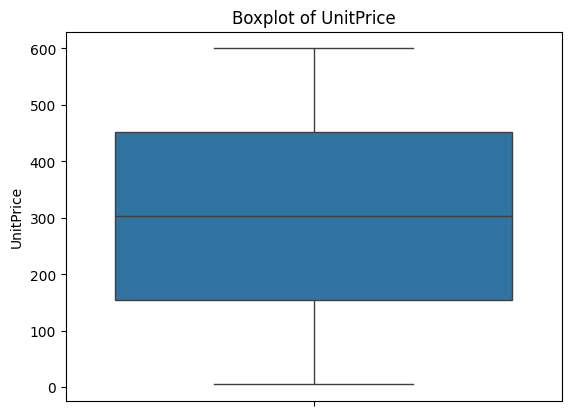

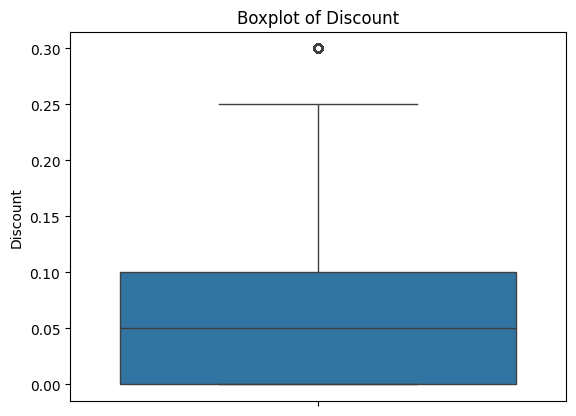

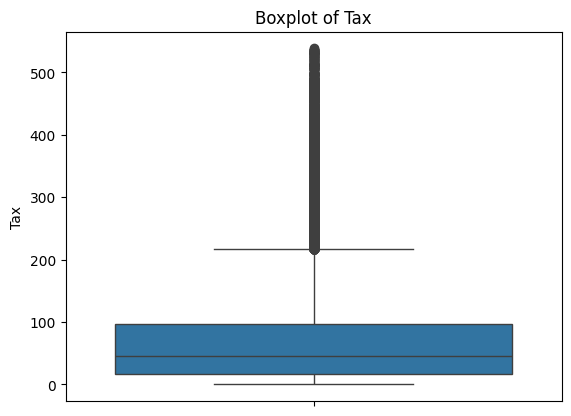

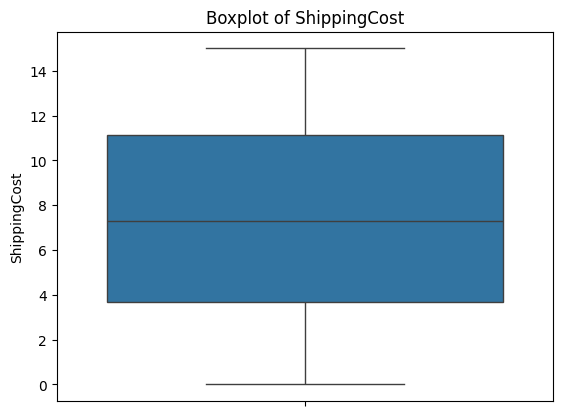

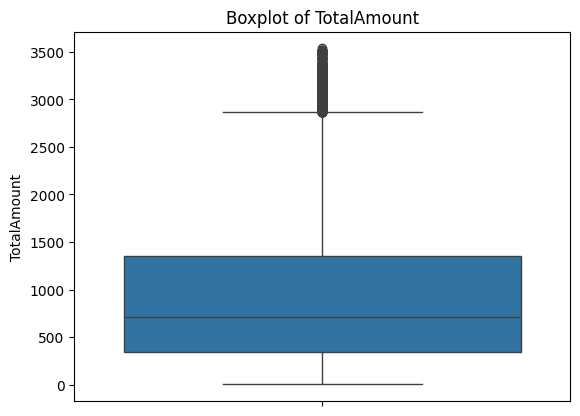

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in essential_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [31]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper, upper,np.where(df[col] < lower, lower, df[col]))
    return df


In [39]:
model_ready = pd.get_dummies(df,drop_first=True, dtype=int)


In [40]:
model_ready.head()

,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,month,day,Category_Clothing,...,City_San Antonio,City_San Diego,City_San Francisco,City_San Jose,City_Seattle,City_Washington,Country_Canada,Country_India,Country_United Kingdom,Country_United States
0,2023-01-31,3,106.59,0.00,0.00,0.09,319.86,1,31,False,...,0,0,0,0,0,1,0,1,0,0
1,2023-12-30,1,251.37,0.05,19.10,1.74,259.64,12,30,False,...,0,0,0,0,0,0,0,0,0,1
2,2022-05-10,3,35.03,0.10,7.57,5.91,108.06,5,10,True,...,0,0,0,0,0,0,0,0,0,1
3,2023-07-18,5,33.58,0.15,11.42,5.53,159.66,7,18,False,...,0,0,0,0,0,0,0,1,0,0
4,2023-02-04,2,515.64,0.25,38.67,9.23,821.36,2,4,True,...,1,0,0,0,0,0,1,0,0,0


In [42]:
df.dtypes

,0
OrderDate,datetime64[ns]
Quantity,int64
UnitPrice,float64
Discount,float64
Tax,float64
...,...
City_Washington,int64
Country_Canada,int64
Country_India,int64
Country_United Kingdom,int64
